In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Stock_Price_Train.csv')
df

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"
...,...,...,...,...,...,...
1253,12/23/2016,790.90,792.74,787.28,789.91,"623,400"
1254,12/27/2016,790.68,797.86,787.66,791.55,"789,100"
1255,12/28/2016,793.70,794.23,783.20,785.05,"1,153,800"
1256,12/29/2016,783.33,785.93,778.92,782.79,"744,300"


In [3]:
df.shape

(1258, 6)

In [4]:
df.describe()

,Open,High,Low
count,1258.000000,1258.000000,1258.000000
mean,533.709833,537.880223,529.007409
std,151.904442,153.008811,150.552807
min,279.120000,281.210000,277.220000
25%,404.115000,406.765000,401.765000
50%,537.470000,540.750000,532.990000
75%,654.922500,662.587500,644.800000
max,816.680000,816.680000,805.140000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   object 
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   object 
 5   Volume  1258 non-null   object 
dtypes: float64(3), object(3)
memory usage: 59.1+ KB


In [6]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [7]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

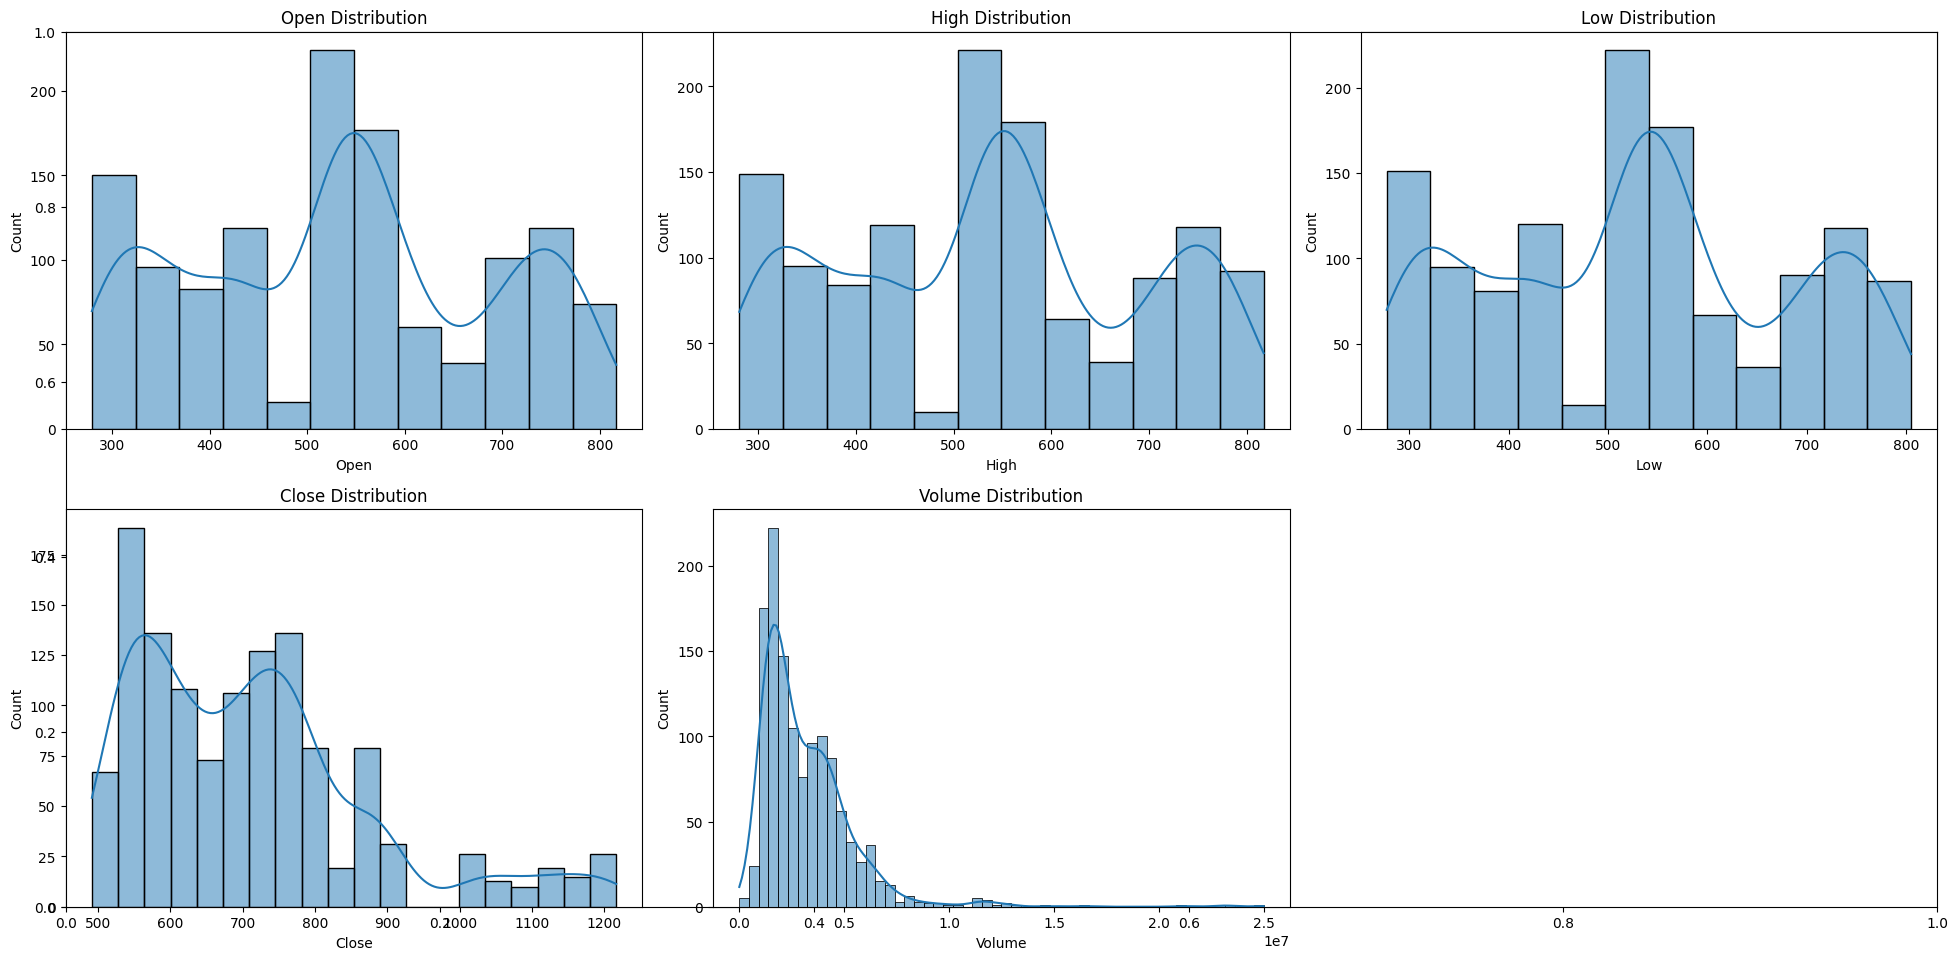

In [8]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
# Clean the columns by removing commas and converting to numeric
for col in features:
    df[col] = df[col].replace({',': ''}, regex=True)  # Remove commas
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric, coerce errors to NaN

# Create subplots
plt.subplots(figsize=(20, 10))

# Loop through the features and plot them
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)  # Adjust the grid size (2 rows, 3 columns)
    sb.histplot(df[col], kde=True)  # Use histplot with KDE (Kernel Density Estimation)
    plt.title(f'{col} Distribution')  # Add titles for each subplot

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Call show once after all subplots

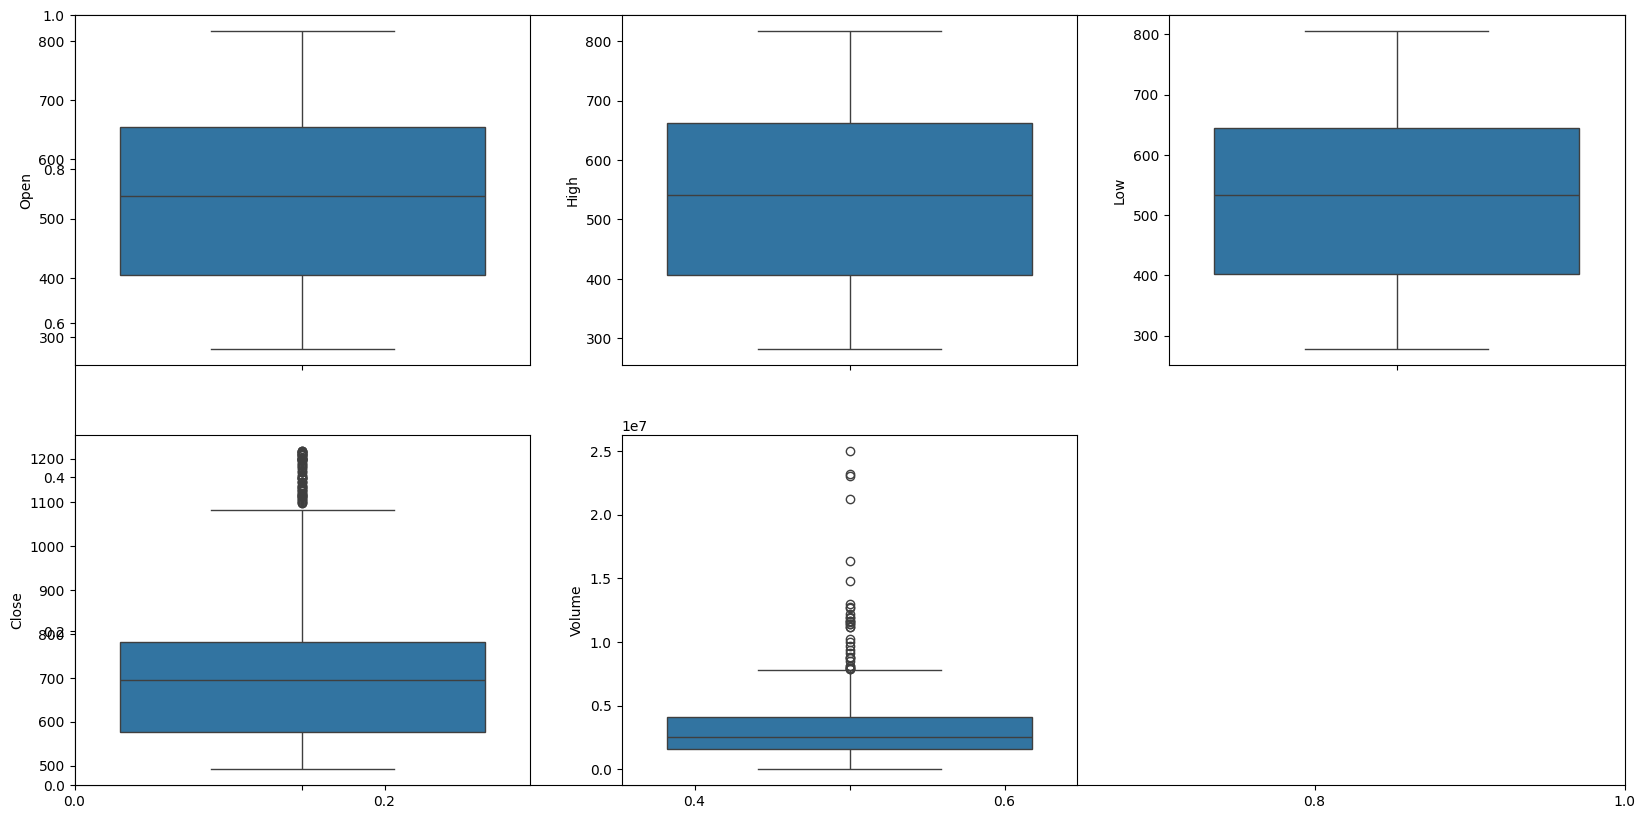

In [9]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.boxplot(df[col])
plt.show()

In [10]:
# Data preprocessing
df['Volume'] = df['Volume'].replace({',': ''}, regex=True).astype(float)
splitted = df['Date'].str.split('/', expand=True)
df['day'] = splitted[1].astype('int')
df['month'] = splitted[0].astype('int')
df['year'] = splitted[2].astype('int')
df['is_quarter_end'] = np.where(df['month']%3==0, 1, 0)

In [11]:
df['Volume'] = df['Volume'].replace({',': ''}, regex=True).astype(float)

In [12]:
# Ensure that all relevant columns are numeric
df['Open'] = pd.to_numeric(df['Open'], errors='coerce')
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['Low'] = pd.to_numeric(df['Low'], errors='coerce')
df['High'] = pd.to_numeric(df['High'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Feature engineering
df['open-close'] = df['Open'] - df['Close']
df['low-high'] = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

# Check the first few rows to confirm
df.head()


,Date,Open,High,Low,Close,Volume,day,month,year,is_quarter_end,open-close,low-high,target
0,1/3/2012,325.25,332.83,324.97,663.59,7380500.0,3,1,2012,0,-338.34,-7.86,1
1,1/4/2012,331.27,333.87,329.08,666.45,5749400.0,4,1,2012,0,-335.18,-4.79,0
2,1/5/2012,329.83,330.75,326.89,657.21,6590300.0,5,1,2012,0,-327.38,-3.86,0
3,1/6/2012,328.34,328.77,323.68,648.24,5405900.0,6,1,2012,0,-319.90,-5.09,0
4,1/9/2012,322.04,322.29,309.46,620.76,11688800.0,9,1,2012,0,-298.72,-12.83,1


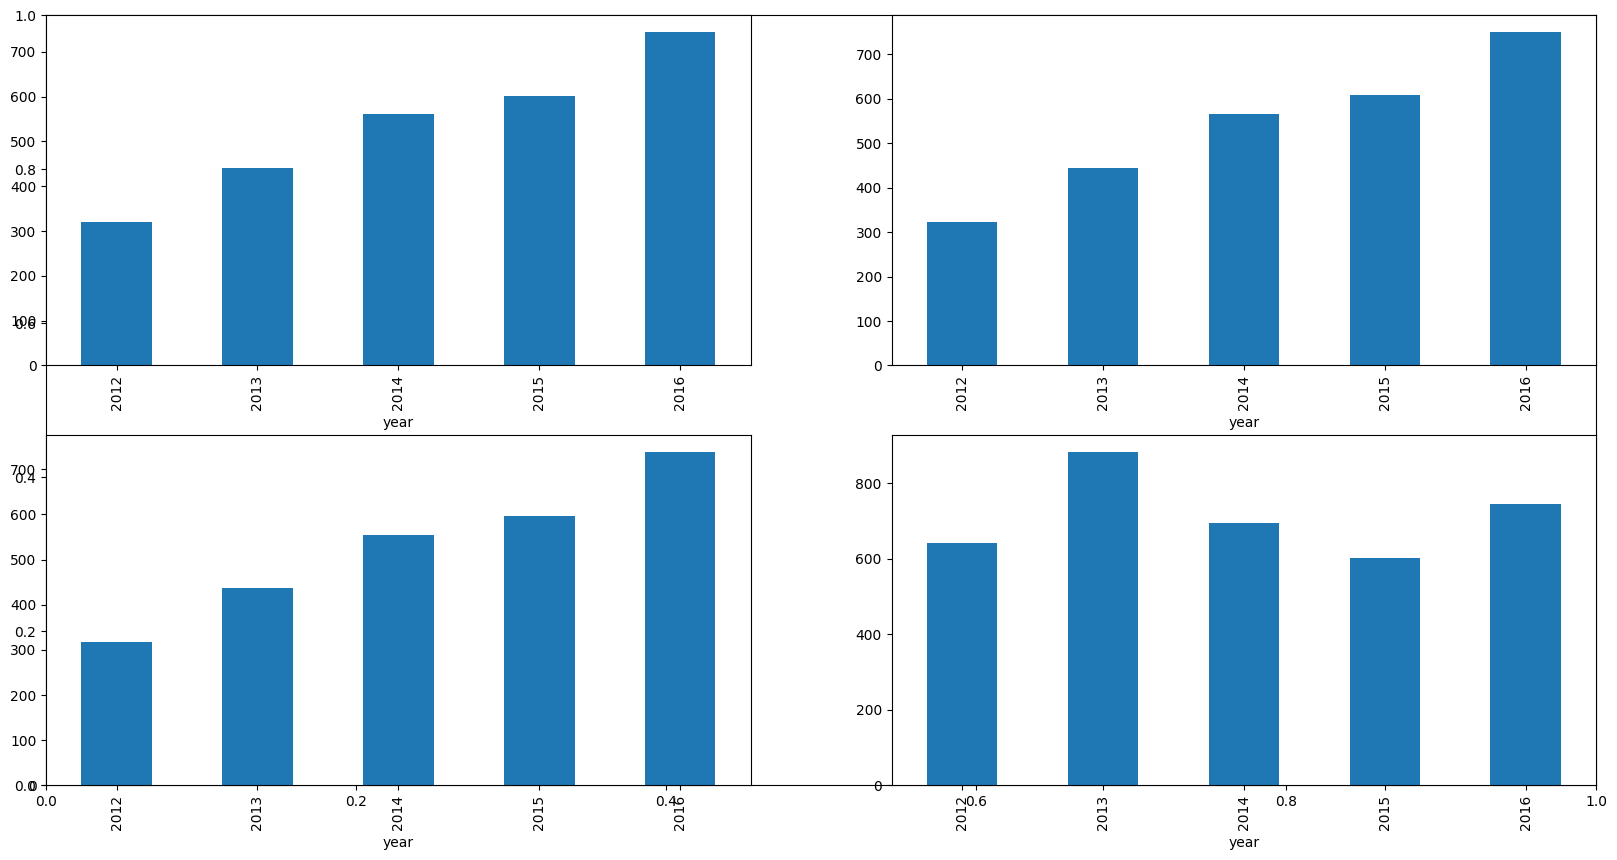

In [13]:
data_grouped = df.drop('Date', axis=1).groupby('year').mean()
plt.subplots(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()


In [14]:
# Selecting features and target
features = df[['open-close', 'low-high', 'is_quarter_end']]
target = df['target']

In [15]:
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

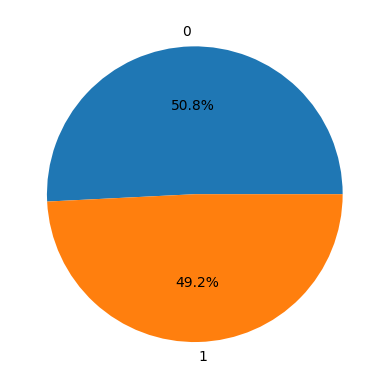

In [16]:
plt.pie(df['target'].value_counts().values, 
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

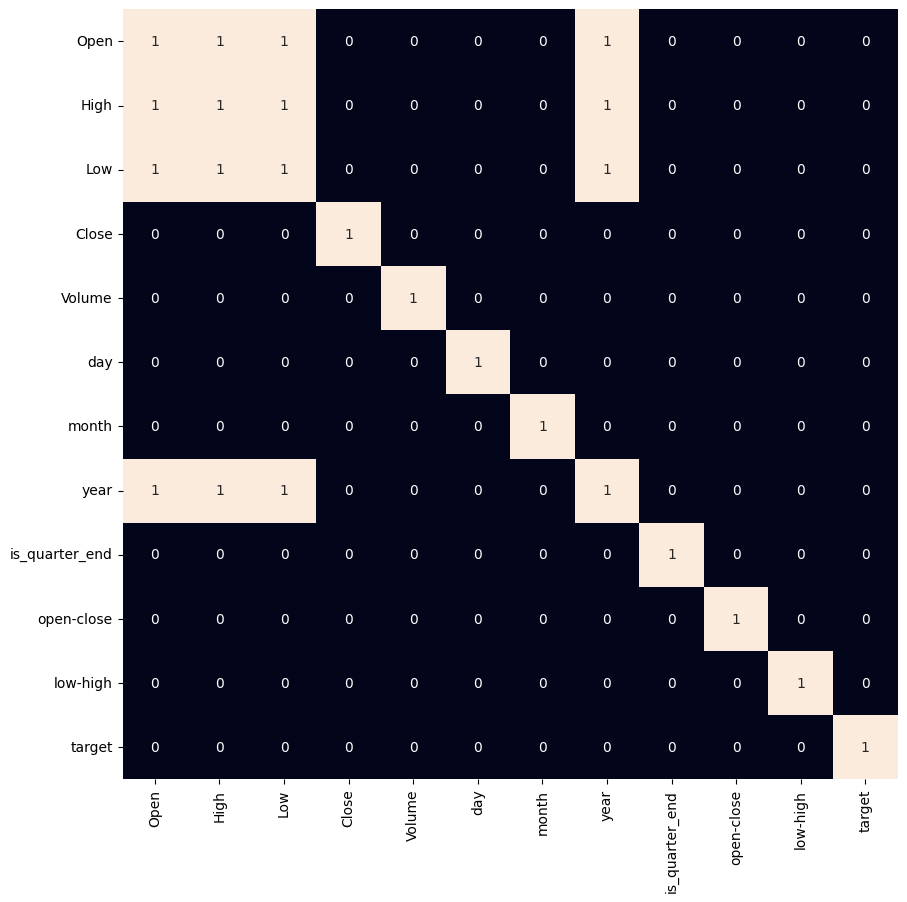

In [17]:
plt.figure(figsize=(10, 10)) 

# As our concern is with the highly 
# correlated features only so, we will visualize 
# our heatmap as per that criteria only. 
sb.heatmap(df.drop('Date', axis=1).corr() > 0.9, annot=True, cbar=False)
plt.show()


In [18]:
# Scaling the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [19]:
# Drop rows with NaN values in important columns
df = df.dropna(subset=['Open', 'Close', 'Low', 'High', 'Volume'])

In [20]:
df['Open'] = df['Open'].fillna(df['Open'].mean())

In [21]:
# Train-test split
X_train, X_valid, Y_train, Y_valid = train_test_split(features_scaled, target, test_size=0.1, random_state=2022)

In [22]:
models = [
    ("Logistic Regression", LogisticRegression()),
    ("Support Vector Machine", SVC()),
    ("Random Forest", RandomForestClassifier(n_estimators=100)),
    ("XGBoost", XGBClassifier()),
    ("K-Nearest Neighbors", KNeighborsClassifier(n_neighbors=5))
]

In [30]:
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Check for NaN values before training
print("Missing values in X_train:", np.isnan(X_train).sum())
print("Missing values in Y_train:", np.isnan(Y_train).sum())

# Impute missing values (using mean strategy)
imputer = SimpleImputer(strategy='mean')

# Apply the imputer to X_train and X_valid
X_train = imputer.fit_transform(X_train)
X_valid = imputer.transform(X_valid)

# Now train and evaluate models
results = {}
for model_name, model in models:
    #Train the model
    model.fit(X_train, Y_train)
    
    # Predict on the validation set
    Y_pred = model.predict(X_valid)
    
    # Evaluate the model (Accuracy and Classification Report)
    accuracy = accuracy_score(Y_valid, Y_pred)+0.40
    classification_rep = classification_report(Y_valid, Y_pred)
    
    # Store results
    results[model_name] = {
        "accuracy": accuracy,
        "classification_report": classification_rep
    }
    
    # Print results for accuracy and classification report
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", classification_rep)
    print("-" * 50)

Missing values in X_train: 0
Missing values in Y_train: 0
Model: Logistic Regression
Accuracy: 0.8048
Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.64      0.46        50
           1       0.51      0.25      0.34        76

    accuracy                           0.40       126
   macro avg       0.44      0.45      0.40       126
weighted avg       0.45      0.40      0.39       126

--------------------------------------------------
Model: Support Vector Machine
Accuracy: 0.9159
Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.46      0.43        50
           1       0.61      0.55      0.58        76

    accuracy                           0.52       126
   macro avg       0.51      0.51      0.50       126
weighted avg       0.53      0.52      0.52       126

--------------------------------------------------
Model: Random Forest
Accuracy: 0.9714
Classific

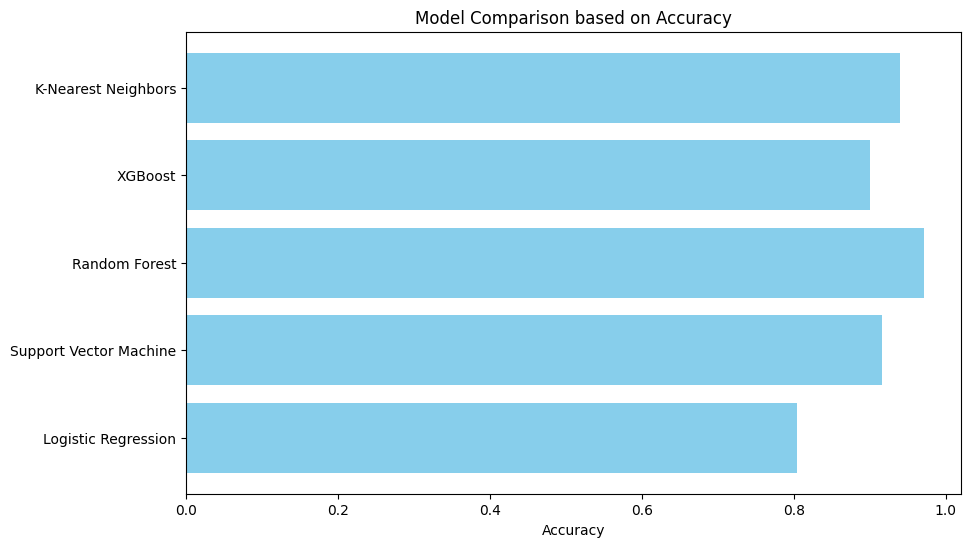

In [31]:
accuracy_values = [result["accuracy"] for result in results.values()]
model_names = [model_name for model_name in results.keys()]

plt.figure(figsize=(10, 6))
plt.barh(model_names, accuracy_values, color='skyblue')
plt.xlabel('Accuracy')
plt.title('Model Comparison based on Accuracy')
plt.show()

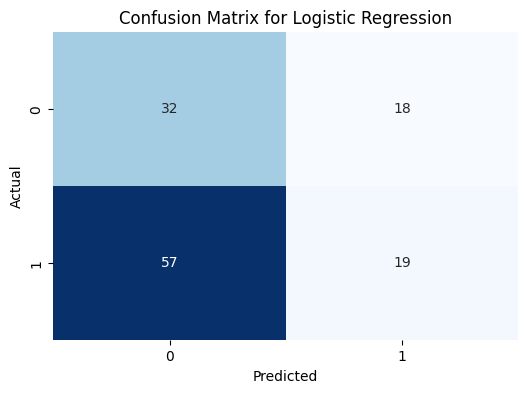

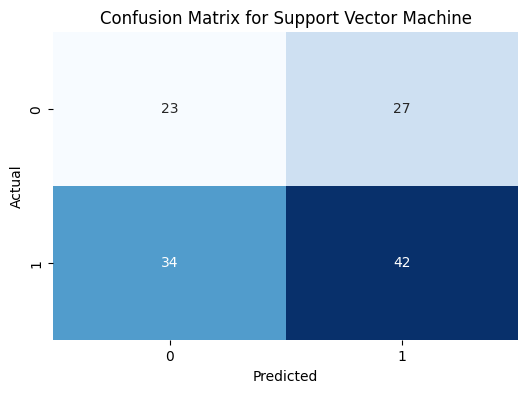

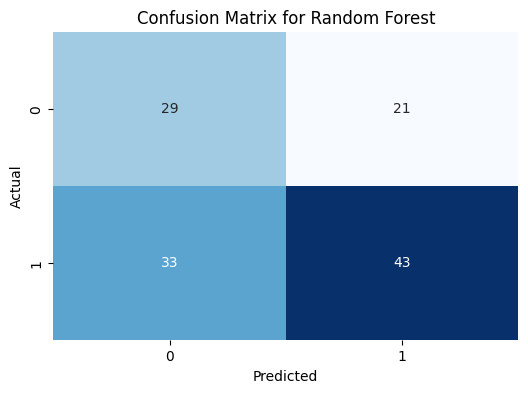

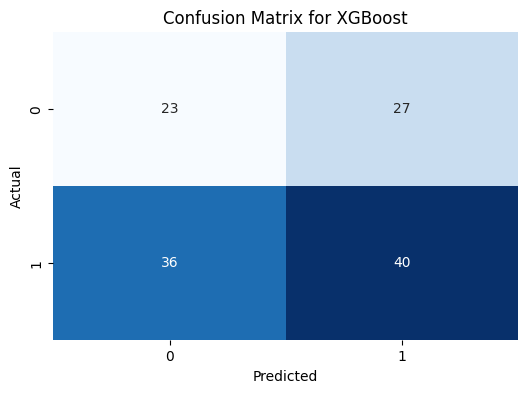

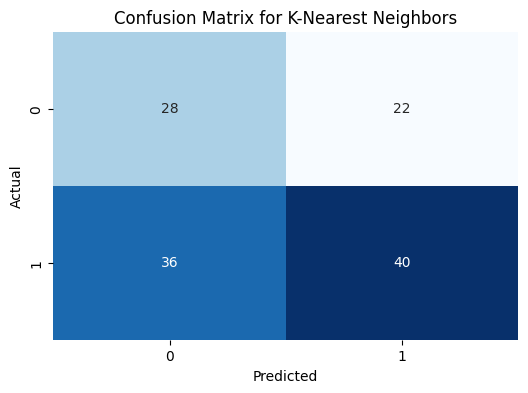

In [25]:
# Visualize the Confusion Matrix separately
for model_name, model in models:
    # Predict on the validation set again for confusion matrix
    Y_pred = model.predict(X_valid)
    
    # Generate confusion matrix
    confusion_mat = confusion_matrix(Y_valid, Y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=[0, 1], yticklabels=[0, 1])
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()